In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
P=3
alpha=0.001
sigma=1e7
mur=32
mu0=4*np.pi*1e-7
vol=26.833234653902096

In [10]:
# Select directory
directory="Results/CSG_Tetra/al_0.001_mu_32_sig_1e7/1e-3-1e12_500_el_25794_ord_"+str(P)+"_POD_13_1e-6"

ck=np.genfromtxt(directory+'/Data/Amplitudes.csv', delimiter=',')
xi=np.genfromtxt(directory+'/Data/Modes.csv', delimiter=',')
Omega=np.genfromtxt(directory+'/Data/Frequencies.csv', delimiter=',')
time=np.genfromtxt(directory+'/Data/Time.csv', delimiter=',')
Sgn_step= np.genfromtxt(directory+'/Data/Sgn_step.csv', delimiter=',')
Sgn_impulse= np.genfromtxt(directory+'/Data/Sgn_impulse.csv', delimiter=',')
TensorArray= np.genfromtxt(directory+'/Data/Tensors.csv', delimiter=',', dtype=complex)
Eigenvalues=np.genfromtxt(directory+'/Data/Eigenvalues.csv', delimiter=',', dtype=complex)
Minf= np.genfromtxt(directory+'/Data/Minf.csv', delimiter=',')
N0= np.genfromtxt(directory+'/Data/N0.csv', delimiter=',')

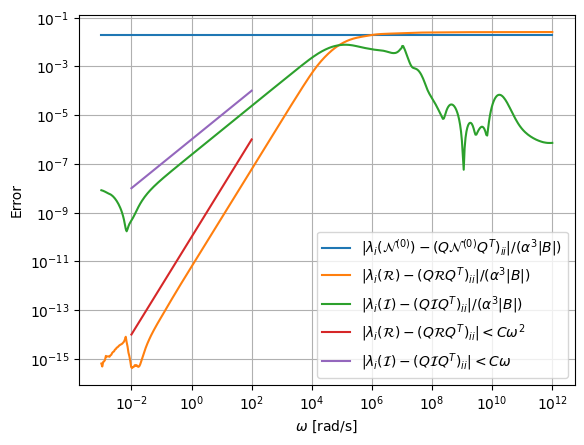

In [11]:
uinf,Qinf=np.linalg.eig(Minf)
myord=np.argsort(np.abs(uinf))
uinf=uinf[myord]
Qinf=Qinf[:,myord]

uN0,QN0=np.linalg.eig(N0)
myord=np.argsort(np.abs(uN0))
uN0=uN0[myord]
QN0=QN0[:,myord]
QN0=QN0[myord,:]

utest=np.transpose(Qinf)@np.real(N0)@Qinf
myord=np.argsort(np.diag(np.abs(utest)))
utest=utest[:,myord]
utest=utest[myord,:]

errorsN0=np.linalg.norm(uN0-np.diag(utest))*np.ones(len(Omega))
  

# Check the similarity of applying Qinf
errorsre=np.zeros(len(Omega))
errorsim=np.zeros(len(Omega))

for n in range(len(Omega)):
    lamre=np.real(Eigenvalues[n])
    Ten=TensorArray[n,:]
    MPT=np.zeros((3,3),dtype=complex)
    MPT[0,0]=Ten[0]
    MPT[0,1]=Ten[1]
    MPT[0,2]=Ten[2]
    MPT[1,0]=Ten[3]
    MPT[1,1]=Ten[4]
    MPT[1,2]=Ten[5]
    MPT[2,0]=Ten[6]
    MPT[2,1]=Ten[7]
    MPT[2,2]=Ten[8]
    ure,Qre=np.linalg.eig(np.real(MPT-N0))
    myord=np.argsort(np.abs(ure))
    ure=ure[myord]
    #Qre=Qre[:,myord]
    uim,Qim=np.linalg.eig(np.imag(MPT))
    myord=np.argsort(uim)
    uim=uim[myord]
    #Qim=Qim[:,myord]
    # Compare
    #print(MPT)
    utest=np.transpose(Qinf)@np.real(MPT-N0)@Qinf
    myord=np.argsort(np.diag(np.abs(utest)))
    utest=utest[:,myord]
    utest=utest[myord,:]
    
    #errorsre[n]=np.linalg.norm(np.diag(ure)-np.diag(np.diag(utest)))
    errorsre[n]=np.linalg.norm(ure-np.diag(utest))
    
    #print(errorsre[n]/alpha**3/vol,ure,np.diag(utest))
    
    utest=np.transpose(Qinf)@np.imag(MPT)@Qinf
    myord=np.argsort(np.diag(utest))
    utest=utest[:,myord]
    utest=utest[myord,:]
    
    errorsim[n]=np.linalg.norm(uim-np.diag(utest))
    #print(errorsim[n]/alpha**3/vol,uim,np.diag(utest))
    
plt.figure()
plt.loglog(Omega,errorsN0/alpha**3/vol,label=r"$| \lambda_i({\cal N}^{(0)})-(Q{\cal N}^{(0)} Q^T)_{ii}|/ (\alpha^3|B|)$")
plt.loglog(Omega,errorsre/alpha**3/vol,label=r"$| \lambda_i({\cal R})-(Q{\cal R} Q^T)_{ii}|/ (\alpha^3|B|)$")
plt.loglog(Omega,errorsim/alpha**3/vol,label=r"$| \lambda_i({\cal I})-(Q{\cal I} Q^T)_{ii}|/ (\alpha^3|B|)$")


#log error = 2*log omega +c
#c=log 1e-17-(log 1e-2)*2
c1=10**(np.log10(1e-14)-2*np.log10(1e-2))
line1=np.array(([[1e-2, 1e-14],[1e2, 10**(np.log10(1e2)*2+np.log10(c1) )]]))
plt.plot(line1[:,0],line1[:,1],label=r"$| \lambda_i({\cal R})-(Q{\cal R} Q^T)_{ii}|< C \omega^2$")
c2=10**(np.log10(1e-8)-np.log10(1e-2))
line2=np.array(([[1e-2, 1e-8],[1e2, 10**(np.log10(1e2)+np.log10(c2))]]))
plt.plot(line2[:,0],line2[:,1],label=r"$| \lambda_i({\cal I})-(Q{\cal I} Q^T)_{ii}|<  C \omega$")



plt.legend()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Error")
plt.grid()

500
500
500


/tmp/user/10925/ipykernel_3921858/789882677.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))


(0.0, 2.25)

<Figure size 640x480 with 0 Axes>

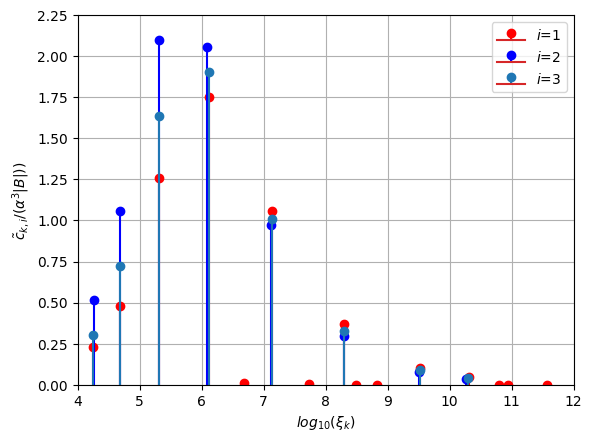

In [20]:
# Compare the modes and amplitudes
plt.figure()
col=['r','b','x']
plt.figure()
for i in range(3):
    nfound=len(xi[:,i])
    ckp=ck[0:nfound,i]
    xip=xi[0:nfound,i]
    print(nfound)
    plt.stem(np.log10(np.abs(xip[1:])), ckp[1:]/(alpha**3*vol),col[i],label=r"$i$="+str(i+1))

    plt.xlabel(r'$log_{10}(\xi_{k})$')
    plt.ylabel(r'$\tilde{c}_{k,i}/ (\alpha^3 |B|))$')

plt.grid()
plt.legend()

    #plt.savefig("results/bigspring_amp_modes_ev"+str(i+1)+".pdf")
plt.xlim([4,12])
plt.ylim([0,2.25])


/tmp/user/10925/ipykernel_3921858/100697099.py:10: RuntimeWarning: divide by zero encountered in divide
  DRSF+=ckp[n]/(1+1j*Omega/xip[n])
/tmp/user/10925/ipykernel_3921858/100697099.py:10: RuntimeWarning: invalid value encountered in divide
  DRSF+=ckp[n]/(1+1j*Omega/xip[n])


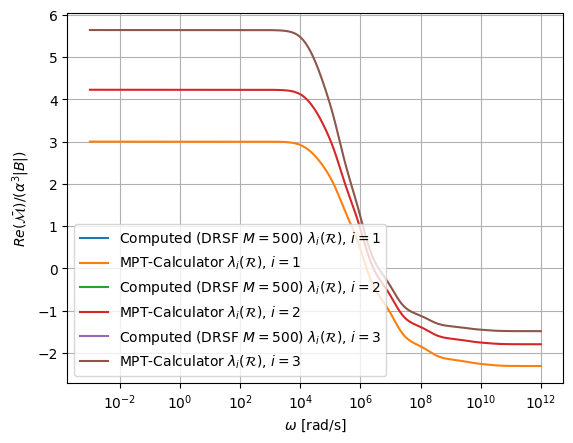

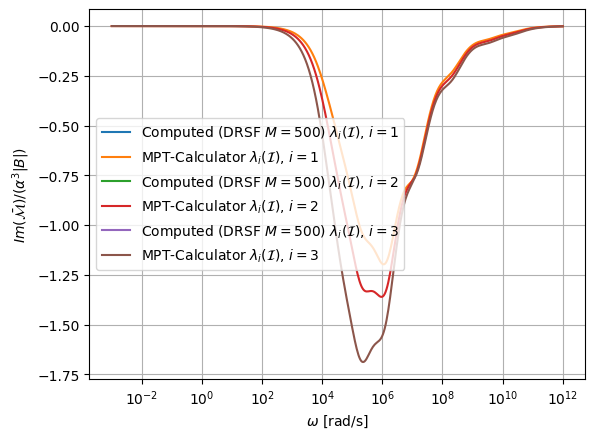

In [19]:
N=len(Omega)
for i in range(3):
    #DRSF=MPTinf_ob[i,i]*np.ones((N),dtype=complex)
    nfound=len(xi[:,0])
    ckp=ck[0:nfound,i]
    xip=xi[:,i]
    # We need to use e.values of MPTinf and take account of ordering this is now done in getimpulse_step
    DRSF=(ckp[0])*np.ones((N),dtype=complex)
    for n in range(1,nfound):
        DRSF+=ckp[n]/(1+1j*Omega/xip[n])
    plt.figure(1)
    plt.semilogx(Omega,np.real(DRSF)/(alpha**3*vol),label=r"Computed (DRSF $M=500$) $\lambda_i({\cal R})$, $i=$"+str(i+1))
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal R})$, $i=$"+str(i+1))
    
    plt.figure(2)
    plt.semilogx(Omega,np.imag(DRSF)/(alpha**3*vol),label=r"Computed (DRSF $M=500$) $\lambda_i({\cal I})$, $i=$"+str(i+1))
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/(alpha**3*vol),label=r"MPT-Calculator $\lambda_i({\cal I})$, $i=$"+str(i+1))
                 
  
plt.figure(1)

plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Re(\bar{\cal M})/(\alpha^3|B|)$")
plt.grid()
plt.legend()
#plt.savefig("results/tet/computed_realmpt_M500_tet.pdf")

plt.figure(2)
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"$Im(\bar{\cal M})/(\alpha^3|B|)$")
plt.legend()
plt.grid()
#plt.savefig("results/tet/computed_imagmpt_M500_tet.pdf")
plt.show()



[8.06492981e-08 1.50909834e-07 1.13712526e-07]


Text(0, 0.5, '-Im$({\\cal M})/(\\alpha^3|B|)$')

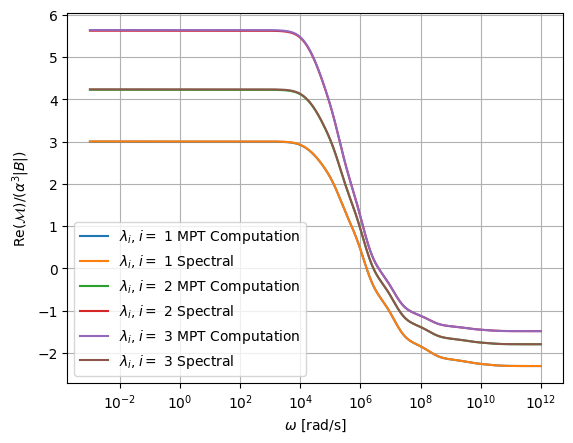

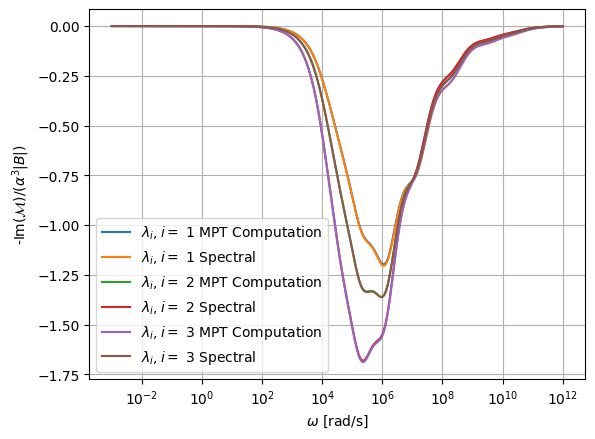

In [13]:
# Obtain MPT from computed ck,xi
sMPT=np.zeros((len(Omega),3),dtype=complex)
dum,Q=np.linalg.eig(Minf)
lN0=np.diag(np.transpose(Q)@N0@Q)
print(lN0)
n=0
for omega in Omega:
    sMPT[n,:]=lN0[:]
    for k in range(1,len(xi)):
        s=1j*omega
        sk=-xi[k]
        sMPT[n,:]+=-ck[k,:]*(s/(s-sk))
    n=n+1


plt.figure(1)
plt.figure(2)
scale=vol*alpha**3
for i in range(3):
    plt.figure(1)
    plt.semilogx(Omega,np.real(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
    plt.semilogx(Omega,np.real(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Spectral")
            
    plt.figure(2)
    plt.semilogx(Omega,-np.imag(Eigenvalues[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" MPT Computation")
    plt.semilogx(Omega,np.imag(sMPT[:,i])/scale,label=r"$\lambda_i, i=$ "+str(i+1)+" Spectral")

plt.figure(1)
plt.grid()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"Re$({\cal M})/(\alpha^3|B|)$")
plt.legend()

plt.figure(2)
plt.legend()
plt.grid()
plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel(r"-Im$({\cal M})/(\alpha^3|B|)$")


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/user/10925/ipykernel_3921858/732157193.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.semilogx(time,Sgn_step[:,i]/scale,label="Numerical Tetrahedron step, $\lambda_i$, $i$="+str(i+1))


Text(0, 0.5, '-$\\lambda_i/(\\alpha^3 |B|)$')

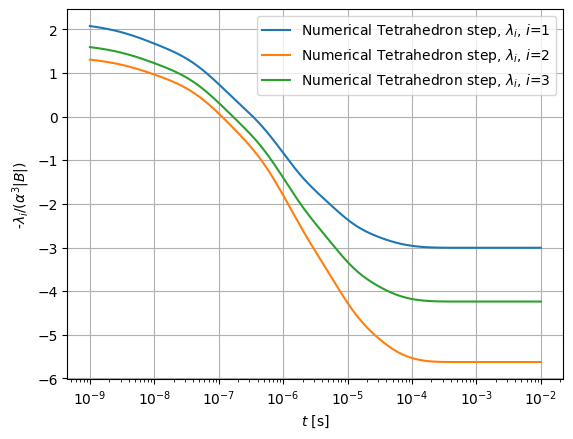

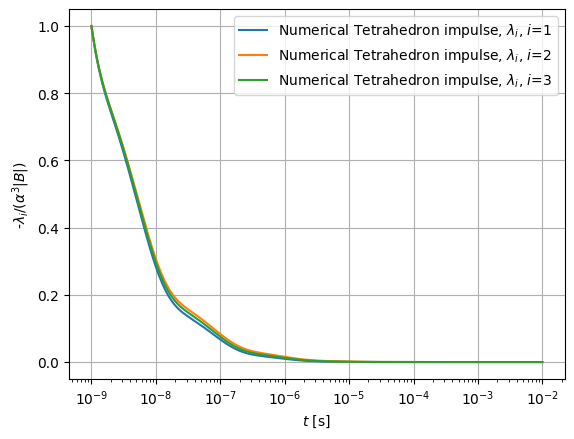

In [21]:
# Important note this is -lambda response as it tends to -1 for large time (ie -lambda(N0)(2*pi*alpha^3))
plt.figure(1)
scale=vol*alpha**3
for i in range(3):
    #scale=Sgn_step[0,i]
    plt.semilogx(time,Sgn_step[:,i]/scale,label="Numerical Tetrahedron step, $\lambda_i$, $i$="+str(i+1))
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(\alpha^3|B|)$")



plt.figure(2)
for i in range(3):
    scale=Sgn_impulse[0,i]
    plt.semilogx(time,Sgn_impulse[:,i]/scale,label=r"Numerical Tetrahedron impulse, $\lambda_i$, $i$="+str(i+1))
    
plt.legend()
plt.grid()
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"-$\lambda_i/(\alpha^3 |B|)$")